In [1]:
from google.colab import files
uploaded = files.upload()

Saving wine.data to wine.data


importing libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

In [4]:
df = pd.read_csv("wine.data", header=None)

# Define column names based on the UCI Wine dataset documentation
column_names = [
    'class', 'alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash',
    'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols',
    'proanthocyanins', 'color_intensity', 'hue',
    'od280/od315_of_diluted_wines', 'proline'
]
df.columns = column_names # Assign column names

target_col = "class"  # Now 'class' exists as a column

X = df.drop(columns=[target_col])
y = df[target_col]

print(df.head())

   class  alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  \
0      1    14.23        1.71  2.43               15.6        127   
1      1    13.20        1.78  2.14               11.2        100   
2      1    13.16        2.36  2.67               18.6        101   
3      1    14.37        1.95  2.50               16.8        113   
4      1    13.24        2.59  2.87               21.0        118   

   total_phenols  flavanoids  nonflavanoid_phenols  proanthocyanins  \
0           2.80        3.06                  0.28             2.29   
1           2.65        2.76                  0.26             1.28   
2           2.80        3.24                  0.30             2.81   
3           3.85        3.49                  0.24             2.18   
4           2.80        2.69                  0.39             1.82   

   color_intensity   hue  od280/od315_of_diluted_wines  proline  
0             5.64  1.04                          3.92     1065  
1             4.38  1.05  

standardization

In [5]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

evaluation using logistic regression

In [6]:
def evaluate(X, y):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    model = LogisticRegression(max_iter=500)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')

    return acc, f1, y_test, y_pred

In [7]:
acc_orig, f1_orig, y_test, y_pred = evaluate(X_scaled, y)

print("Original Data")
print("Accuracy:", acc_orig)
print("F1 Score:", f1_orig)

Original Data
Accuracy: 0.9722222222222222
F1 Score: 0.9719701552732407


lda(1d+2d)

In [8]:
results = {}

for n in [1, 2]:
    lda = LinearDiscriminantAnalysis(n_components=n)
    X_lda = lda.fit_transform(X_scaled, y)

    acc, f1, y_test, y_pred = evaluate(X_lda, y)

    results[n] = (acc, f1)

    print(f"\nLDA ({n}D)")
    print("Accuracy:", acc)
    print("F1 Score:", f1)

    # Save projection
    proj_df = pd.DataFrame(X_lda, columns=[f"LD{i+1}" for i in range(n)])
    proj_df["Class"] = y.values
    proj_df["SampleId"] = np.arange(len(proj_df))

    proj_df.to_csv(f"lda_projection_{n}D.csv", index=False)


LDA (1D)
Accuracy: 0.8888888888888888
F1 Score: 0.8885140200929674

LDA (2D)
Accuracy: 1.0
F1 Score: 1.0


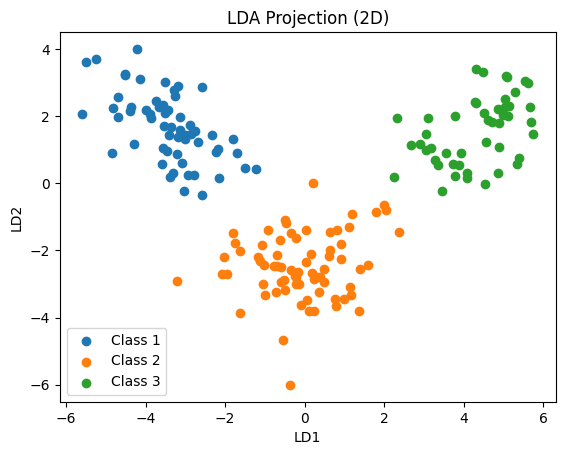

In [9]:
lda = LinearDiscriminantAnalysis(n_components=2)
X_lda = lda.fit_transform(X_scaled, y)

plt.figure()
for label in np.unique(y):
    plt.scatter(
        X_lda[y == label, 0],
        X_lda[y == label, 1],
        label=f"Class {label}"
    )

plt.xlabel("LD1")
plt.ylabel("LD2")
plt.title("LDA Projection (2D)")
plt.legend()
plt.show()

confusion matrix

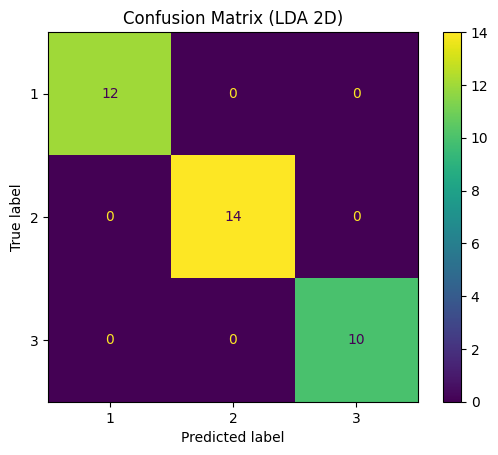

In [10]:
from sklearn.metrics import ConfusionMatrixDisplay

lda = LinearDiscriminantAnalysis(n_components=2)
X_lda = lda.fit_transform(X_scaled, y)

_, _, y_test, y_pred = evaluate(X_lda, y)

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.title("Confusion Matrix (LDA 2D)")
plt.show()

In [11]:
from google.colab import files

files.download("lda_projection_1D.csv")
files.download("lda_projection_2D.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>